In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)


In [3]:
# collect all of our data

acts_Mutographs = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)


acts_TCGA = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/TCGA/results/output_tables/MSA_TCGA/pruned_attribution_MSA_TCGA_SBS_abs_mutations.csv',
                  index_col=0)
# D is SBS288D

acts_Swedish = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/SWEDISH/results/output_tables/MSA_SWEDISH/pruned_attribution_MSA_SWEDISH_SBS_abs_mutations.csv',
                  index_col=0)

# E is SBS288D


acts_gel = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/GEL/results/output_tables/MSA_GEL/pruned_attribution_MSA_GEL_SBS_abs_mutations.csv',
                  index_col=0)
acts_gel=acts_gel[acts_gel.sum(axis=1) !=0]

# F is SBS288D 

mutographs_SBSD = acts_Mutographs.loc[:,'SBS288D'] / acts_Mutographs.sum(axis=1)

TCGA_SBSD = acts_TCGA.loc[:,'SBS288D'] /  acts_TCGA.sum(axis=1)

Swedish_SBSD = acts_Swedish.loc[:,'SBS288E'] / acts_Swedish.sum(axis=1)

GEL_SBSD = acts_gel.loc[:,'SBS96F'] / acts_gel.sum(axis=1)


In [5]:


mutographs_SBSD_df = pd.DataFrame(mutographs_SBSD,
                              columns = ['relative_SBS_D_activity'])

mutographs_SBSD_df['dataset'] = 'Mutographs'
mutographs_SBSD_df['SBS_D'] = acts_Mutographs.loc[:,'SBS288D']
mutographs_SBSD_df['TOTAL'] = acts_Mutographs.sum(axis=1)



TCGA_SBSD_df = pd.DataFrame(TCGA_SBSD,
                              columns = ['relative_SBS_D_activity'])

TCGA_SBSD_df['dataset'] = 'TCGA'
TCGA_SBSD_df['SBS_D'] = acts_TCGA.loc[:,'SBS288D']
TCGA_SBSD_df['TOTAL'] = acts_TCGA.sum(axis=1)



Swedish_SBSD_df = pd.DataFrame(Swedish_SBSD,
                              columns = ['relative_SBS_D_activity'])

Swedish_SBSD_df['dataset'] = 'Swedish'
Swedish_SBSD_df['SBS_D'] = acts_Swedish.loc[:,'SBS288E']
Swedish_SBSD_df['TOTAL'] = acts_Swedish.sum(axis=1)



GEL_SBSD_df = pd.DataFrame(GEL_SBSD,
                              columns = ['relative_SBS_D_activity'])

GEL_SBSD_df['dataset'] = 'GEL'
GEL_SBSD_df['SBS_D'] = acts_gel.loc[:,'SBS96F']
GEL_SBSD_df['TOTAL'] = acts_gel.sum(axis=1)



In [10]:
# num positive for different cohorts 

In [11]:
print(str((GEL_SBSD_df.loc[:,'relative_SBS_D_activity'] > 0).sum()) + ' / ' +  str(len(GEL_SBSD_df)+1))

414 / 1532


In [12]:
print(str((mutographs_SBSD_df.loc[:,'relative_SBS_D_activity'] > 0).sum()) + ' / ' +  str(len(mutographs_SBSD_df)))

428 / 802


In [13]:
print(str((Swedish_SBSD_df.loc[:,'relative_SBS_D_activity'] > 0).sum()) + ' / ' +  str(len(Swedish_SBSD_df)))

388 / 694


In [14]:
print(str((TCGA_SBSD_df.loc[:,'relative_SBS_D_activity'] > 0).sum()) + ' / ' +  str(len(TCGA_SBSD_df)))

218 / 390


In [ ]:
# compare to the mutographs cohorts

In [16]:
from scipy.stats import binomtest

# GEL
binomtest(414, n=1532, p=(428 / 802))

BinomTestResult(k=414, n=1532, alternative='two-sided', statistic=0.27023498694516973, pvalue=3.670631690741001e-97)

In [17]:
# TCGA
binomtest(414, n=1532, p=(218 / 390))

BinomTestResult(k=414, n=1532, alternative='two-sided', statistic=0.27023498694516973, pvalue=6.433487006939514e-116)

In [18]:
# Swedish
binomtest(414, n=1532, p=(388 / 694))

BinomTestResult(k=414, n=1532, alternative='two-sided', statistic=0.27023498694516973, pvalue=6.01313257164114e-116)

In [19]:
all_together = pd.concat([mutographs_SBSD_df,
          TCGA_SBSD_df,
          Swedish_SBSD_df,
          GEL_SBSD_df])

In [20]:
# decided to keep the zero samples
all_together_nonzero = all_together.copy()

In [21]:
all_together_nonzero['OTHER'] = 1 - all_together_nonzero.loc[:,'relative_SBS_D_activity']

In [22]:
tempa = all_together_nonzero.loc[:,['relative_SBS_D_activity','dataset']]
tempa.columns = ['relative_activity','dataset']
tempa['signature'] = 'SBS_D'

tempb = all_together_nonzero.loc[:,['OTHER','dataset']]
tempb.columns = ['relative_activity','dataset']
tempb['signature'] = 'OTHER'

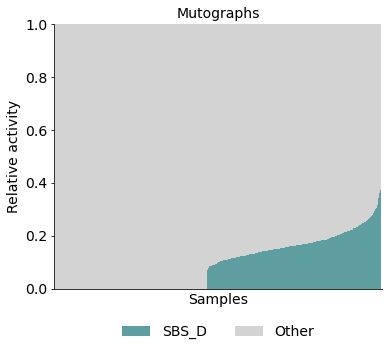

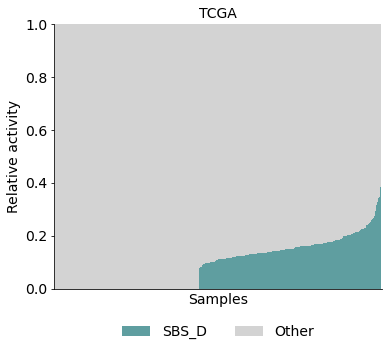

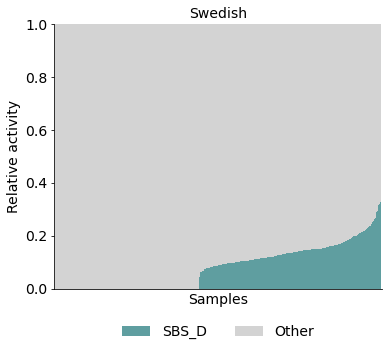

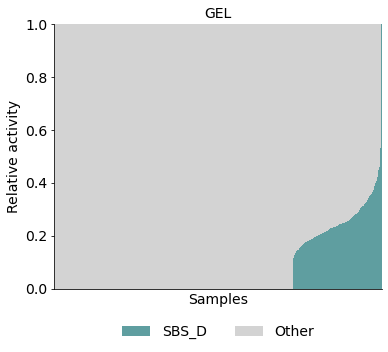

In [23]:
######### Supplementary Figure 5a-d #########

# plots for SBS_D


for dataset in all_together_nonzero.loc[:,'dataset'].unique():


    fig,ax = plt.subplots(figsize=(5.5,5))
    mutographs_sub = all_together_nonzero[all_together_nonzero.loc[:,'dataset']==dataset]

    mutographs_sub.sort_values('relative_SBS_D_activity').loc[:,['relative_SBS_D_activity','OTHER']].plot.bar(stacked=True,ax=ax, width=1,color=['cadetblue','lightgrey'])



    plt.ylim(0,1)
    plt.xticks([])

    ax.legend(frameon=False,labels=['SBS_D','Other'],
                loc='upper center', bbox_to_anchor=(0.5, -0.09),ncols=2,
                fontsize=14)

#     plt.axhline(mutographs_sub.loc[:,'relative_SBS_D_activity'].median(),
#                color='red',label=None)

    plt.ylabel('Relative activity')
    plt.xlabel('Samples')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.title(dataset )

    
    
    

    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(14)
    plt.tight_layout()

#     plt.savefig('reviewer_plots/SBS_D_percentage_' + dataset + '.png',dpi=300)

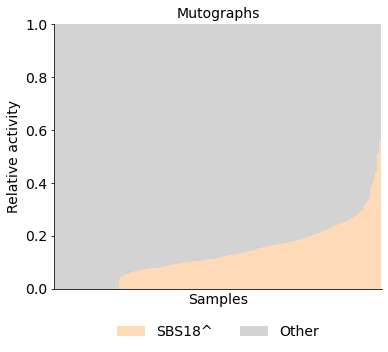

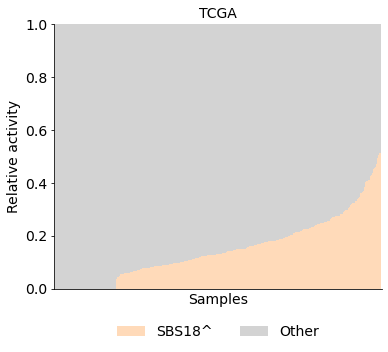

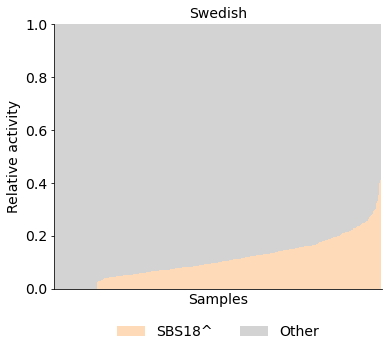

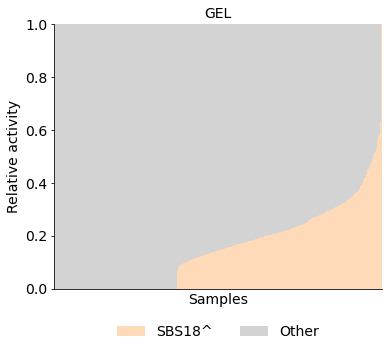

In [24]:
######### Supplementary Figure 5a-d #########

# plots for SBS_B

# we need to do the same thing for SBS_B 
# and this can be a supplementary figure? 


mutographs_SBSB = acts_Mutographs.loc[:,'SBS288B'] / acts_Mutographs.sum(axis=1)

TCGA_SBSB = acts_TCGA.loc[:,'SBS288C'] /  acts_TCGA.sum(axis=1)

Swedish_SBSB = acts_Swedish.loc[:,'SBS288B'] / acts_Swedish.sum(axis=1)

GEL_SBSB = acts_gel.loc[:,'SBS96B'] / acts_gel.sum(axis=1)



#####################################################################################

mutographs_SBSB_df_SBS_B  = pd.DataFrame(mutographs_SBSB,
                              columns = ['relative_SBS_B_activity'])

mutographs_SBSB_df_SBS_B ['dataset'] = 'Mutographs'
mutographs_SBSB_df_SBS_B['SBS_B'] = acts_Mutographs.loc[:,'SBS288B']
mutographs_SBSB_df_SBS_B['TOTAL'] = acts_Mutographs.sum(axis=1)


TCGA_SBSB_df_SBS_B  = pd.DataFrame(TCGA_SBSB,
                              columns = ['relative_SBS_B_activity'])

TCGA_SBSB_df_SBS_B ['dataset'] = 'TCGA'
TCGA_SBSB_df_SBS_B['SBS_B'] = acts_TCGA.loc[:,'SBS288C']
TCGA_SBSB_df_SBS_B['TOTAL'] = acts_TCGA.sum(axis=1)



Swedish_SBSB_df_SBS_B  = pd.DataFrame(Swedish_SBSB,
                              columns = ['relative_SBS_B_activity'])

Swedish_SBSB_df_SBS_B ['dataset'] = 'Swedish'
Swedish_SBSB_df_SBS_B['SBS_B'] = acts_Swedish.loc[:,'SBS288B']
Swedish_SBSB_df_SBS_B['TOTAL'] = acts_Swedish.sum(axis=1)



GEL_SBSB_df_SBS_B  = pd.DataFrame(GEL_SBSB,
                              columns = ['relative_SBS_B_activity'])

GEL_SBSB_df_SBS_B ['dataset'] = 'GEL'
GEL_SBSB_df_SBS_B['SBS_B'] = acts_gel.loc[:,'SBS96B']
GEL_SBSB_df_SBS_B['TOTAL'] = acts_gel.sum(axis=1)


all_together_SBS_B = pd.concat([mutographs_SBSB_df_SBS_B ,
          TCGA_SBSB_df_SBS_B ,
          Swedish_SBSB_df_SBS_B ,
          GEL_SBSB_df_SBS_B ])

all_together_SBS_B_nonzero = all_together_SBS_B.copy()#all_together_SBS_B[all_together_SBS_B.loc[:,'relative_SBS_B_activity']!=0]

all_together_SBS_B_nonzero['OTHER'] = 1 - all_together_SBS_B_nonzero.loc[:,'relative_SBS_B_activity']





for dataset in all_together_SBS_B_nonzero.loc[:,'dataset'].unique():


    fig,ax = plt.subplots(figsize=(5.5,5))
    mutographs_sub = all_together_SBS_B_nonzero[all_together_SBS_B_nonzero.loc[:,'dataset']==dataset]

    mutographs_sub.sort_values('relative_SBS_B_activity').loc[:,['relative_SBS_B_activity','OTHER']].plot.bar(stacked=True,ax=ax, width=1,color=['peachpuff','lightgrey'])



    plt.ylim(0,1)
    plt.xticks([])

    ax.legend(frameon=False,labels=['SBS18^','Other'],
                loc='upper center', bbox_to_anchor=(0.5, -0.09),ncols=2,
                fontsize=14)

#     plt.axhline(mutographs_sub.loc[:,'relative_SBS_B_activity'].median(),
#                color='red',label=None)

    plt.ylabel('Relative activity')
    plt.xlabel('Samples')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.title(dataset 
              )


    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(14)
    plt.tight_layout()

#     plt.savefig('reviewer_plots/SBS_B_percentage_' + dataset + '.png',dpi=300)

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76443/621567050.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_sbsb['OTHER_TOTAL'] = curr_sbsb.loc[:,'TOTAL'] - curr_sbsb.loc[:,'SBS_B']
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76443/621567050.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_sbsd['OTHER_TOTAL'] = curr_sbsd.loc[:,'TOTAL'] - curr_sbsd.loc[:,'SBS_D']
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76443/621567050.py:11: SettingWithCopyW

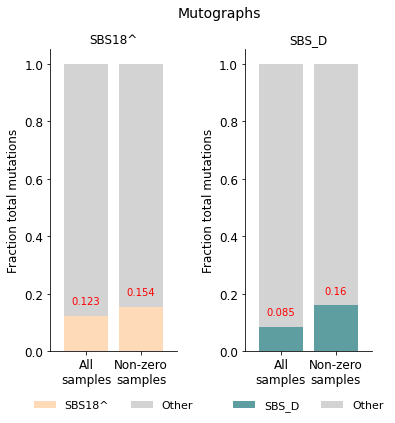

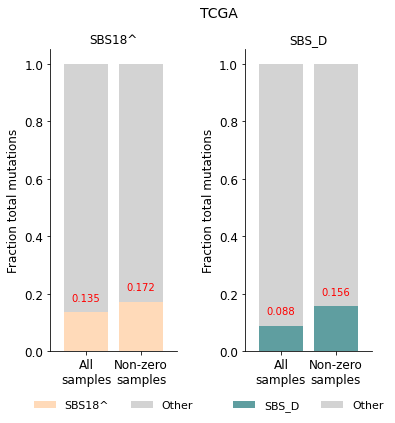

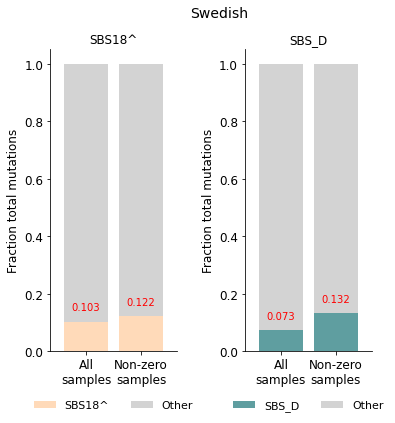

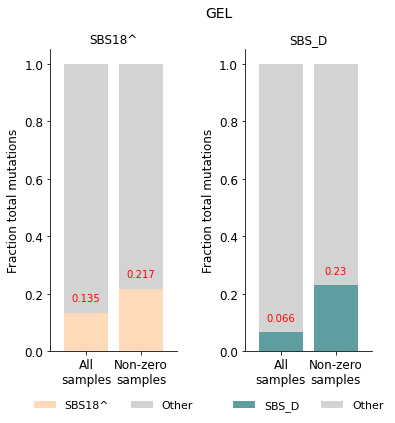

In [25]:
######### Supplementary Figure 5e-h #########

# need to put the bar plots under each of the things
for dataset in all_together_SBS_B_nonzero.loc[:,'dataset'].unique():
    fig,ax = plt.subplots(1,2,figsize=(5.5,6),
                         sharey=False)
    curr_sbsb = all_together_SBS_B_nonzero[all_together_SBS_B_nonzero.loc[:,'dataset']==dataset]
    curr_sbsd = all_together_nonzero[all_together_nonzero.loc[:,'dataset']==dataset]

    
    curr_sbsb['OTHER_TOTAL'] = curr_sbsb.loc[:,'TOTAL'] - curr_sbsb.loc[:,'SBS_B']
    df_for_summary_bar_sbsb = pd.DataFrame(index = ['All samples',
                                              'SBS18^-positive samples'],
                                     columns = ['SBS_B', 'OTHER_TOTAL'])


    df_for_summary_bar_sbsb.loc['All samples'] = curr_sbsb.loc[:,['SBS_B','OTHER_TOTAL']].sum()
    df_for_summary_bar_sbsb.loc['SBS18^-positive samples'] = curr_sbsb[curr_sbsb.loc[:,'SBS_B']>0].loc[:,['SBS_B','OTHER_TOTAL']].sum()
    df_for_summary_bar_sbsb_normed = (df_for_summary_bar_sbsb.T / df_for_summary_bar_sbsb.sum(axis=1)).T     
    
    df_for_summary_bar_sbsb_normed.plot.bar(stacked=True,ax=ax[0],width=.8,color=['peachpuff','lightgrey']
                               )
    ax[0].set_title('SBS18^')
    ax[0].set_xticklabels(['All\nsamples','Non-zero\nsamples'], rotation=0)
    ax[0].legend(frameon=False,labels=['SBS18^','Other'],
                    loc='upper center', bbox_to_anchor=(0.5, -0.13),ncols=2,
                    fontsize=11)
    ax[0].set_ylabel('Fraction total mutations')

    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)

    for item in ([ax[0].title, ax[0].xaxis.label, ax[0].yaxis.label] +
                 ax[0].get_xticklabels() + ax[0].get_yticklabels()):
        item.set_fontsize(12)

        
    import numpy as np
    x = np.arange(2)

    bottom_values = df_for_summary_bar_sbsb_normed.loc[:,'SBS_B']
    top_values = df_for_summary_bar_sbsb_normed.loc[:,'OTHER_TOTAL']
    height = top_values[0]
    bottom = bottom_values[0]
    ax[0].text(
        x[0],                         # x-position
        bottom+.05,         # y-position (middle of the top bar)
        str(round(bottom,3)),                 # label
        ha='center', va='center',    # center alignment
        fontsize=10, color='red'
    )

    height = top_values[1]
    bottom = bottom_values[1]
    ax[0].text(
        x[1],                         # x-position
        bottom+.05,         # y-position (middle of the top bar)
        str(round(bottom,3)),                 # label
        ha='center', va='center',    # center alignment
        fontsize=10, color='red'
    )



    ##################################################
    # SBS_D 

    df_for_summary_bar_sbsd = pd.DataFrame(index = ['All samples',
                                              'SBS_D-positive samples'],
                                     columns = ['SBS_D', 'OTHER'])

    curr_sbsd['OTHER_TOTAL'] = curr_sbsd.loc[:,'TOTAL'] - curr_sbsd.loc[:,'SBS_D']
    df_for_summary_bar_sbsd = pd.DataFrame(index = ['All samples',
                                              'SBS_D-positive samples'],
                                     columns = ['SBS_D', 'OTHER_TOTAL'])


    df_for_summary_bar_sbsd.loc['All samples'] = curr_sbsd.loc[:,['SBS_D','OTHER_TOTAL']].sum()
    df_for_summary_bar_sbsd.loc['SBS_D-positive samples'] = curr_sbsd[curr_sbsd.loc[:,'SBS_D']>0].loc[:,['SBS_D','OTHER_TOTAL']].sum()
    df_for_summary_bar_sbsd_normed = (df_for_summary_bar_sbsd.T / df_for_summary_bar_sbsd.sum(axis=1)).T     
    

#     df_for_summary_bar_sbsd.loc['All samples'] = curr_sbsd.mean()
#     df_for_summary_bar_sbsd.loc['SBS_D-positive samples'] = curr_sbsd[curr_sbsd.loc[:,'SBS_D']>0].mean()
    df_for_summary_bar_sbsd_normed.plot.bar(stacked=True,ax=ax[1],width=.8,color=['cadetblue','lightgrey']
                               )
    ax[1].set_title('SBS_D')
    ax[1].set_xticklabels(['All\nsamples','Non-zero\nsamples'], rotation=0)
    ax[1].legend(frameon=False,labels=['SBS_D','Other'],
                    loc='upper center', bbox_to_anchor=(0.5, -0.13),ncols=2,
                    fontsize=11)
    ax[1].set_ylabel('Fraction total mutations')

    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)

    for item in ([ax[1].title, ax[1].xaxis.label, ax[1].yaxis.label] +
                 ax[1].get_xticklabels() + ax[1].get_yticklabels()):
        item.set_fontsize(12)


    x = np.arange(2)

    bottom_values = df_for_summary_bar_sbsd_normed.loc[:,'SBS_D']
    top_values = df_for_summary_bar_sbsd_normed.loc[:,'OTHER_TOTAL']
    height = top_values[0]
    bottom = bottom_values[0]
    ax[1].text(
        x[0],                         # x-position
        bottom+.05,         # y-position (middle of the top bar)
        str(round(bottom,3)),                 # label
        ha='center', va='center',    # center alignment
        fontsize=10, color='red'
    )

    height = top_values[1]
    bottom = bottom_values[1]
    ax[1].text(
        x[1],                         # x-position
        bottom+.05,         # y-position (middle of the top bar)
        str(round(bottom,3)),                 # label
        ha='center', va='center',    # center alignment
        fontsize=10, color='red'
    )
    
    
    mid = (fig.subplotpars.right + fig.subplotpars.left)/2+.05

    plt.suptitle(dataset, fontsize=14,x=mid )#fontweight='bold')

    
    plt.tight_layout()
#     break
#     plt.savefig('reviewer_plots/summary_bars_SBS_B_SBS_18_' + dataset + '.png',
#                dpi=300)